# Introduction


# Dataset Loading & pre processing


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Imports**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print('Imports OK')

Imports OK


**Upload and load the data**

In [ ]:
# Upload train.csv and test.csv from your computer
from google.colab import files

print('Please upload train.csv and test.csv when the dialog appears...')
uploaded = files.upload()   # a file picker will pop up — select BOTH files

df_train = pd.read_csv('train.csv')
df_test  = pd.read_csv('test.csv')

print(f'Train shape: {df_train.shape}')   # should be (7352, 563)
print(f'Test  shape: {df_test.shape}')    # should be (2947, 563)
print(f'Columns (last 3): {df_train.columns.tolist()[-3:]}')

Please upload train.csv and test.csv when the dialog appears...


Saving test.csv to test.csv
Saving train.csv to train.csv
Train shape: (7352, 563)
Test  shape: (2947, 563)
Columns (last 3): ['angle(Z,gravityMean)', 'subject', 'Activity']


**Data Quality Checks**

In [ ]:
META_COLS    = ['subject', 'Activity']
FEATURE_COLS = [c for c in df_train.columns if c not in META_COLS]

print(f'Feature columns: {len(FEATURE_COLS)}')   # should be 561
print(f'Missing values  — train: {df_train.isnull().sum().sum()},  test: {df_test.isnull().sum().sum()}')
print(f'Duplicate rows  — train: {df_train.duplicated().sum()},  test: {df_test.duplicated().sum()}')

# Check no subject appears in BOTH train and test (important!)
overlap = set(df_train['subject'].unique()) & set(df_test['subject'].unique())
print(f'Subject overlap between train and test: {overlap}')   # should be empty set()

# Zero-variance features (useless for any model)
zero_var = [c for c in FEATURE_COLS if df_train[c].std() == 0]
print(f'Zero-variance features: {len(zero_var)}')   # should be 0

Feature columns: 561
Missing values  — train: 0,  test: 0
Duplicate rows  — train: 0,  test: 0
Subject overlap between train and test: set()
Zero-variance features: 0


**Class distribution Plot**

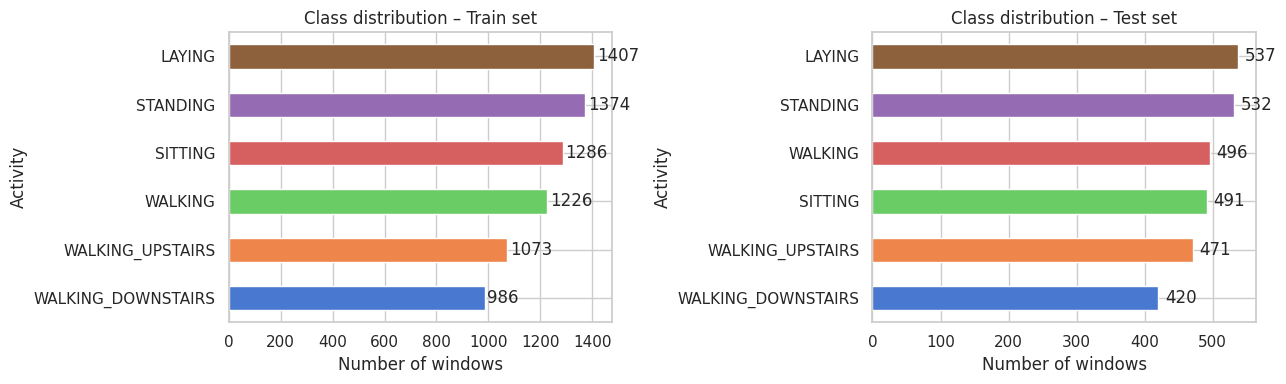

Plot saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, title in zip(axes, [df_train, df_test], ['Train set', 'Test set']):
    counts = df['Activity'].value_counts().sort_values(ascending=True)
    counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(counts)))
    ax.set_title(f'Class distribution – {title}')
    ax.set_xlabel('Number of windows')
    for i, v in enumerate(counts):
        ax.text(v + 10, i, str(v), va='center')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

**Label encoding**

In [ ]:
le = LabelEncoder()
le.fit(pd.concat([df_train['Activity'], df_test['Activity']]))

y_train = le.transform(df_train['Activity'])
y_test  = le.transform(df_test['Activity'])

print('Label mapping:')
for i, name in enumerate(le.classes_):
    print(f'  {i}  →  {name}')

print(f'\ny_train sample: {y_train[:8]}')

Label mapping:
  0  →  LAYING
  1  →  SITTING
  2  →  STANDING
  3  →  WALKING
  4  →  WALKING_DOWNSTAIRS
  5  →  WALKING_UPSTAIRS

y_train sample: [2 2 2 2 2 2 2 2]


**Feature Scaling**

In [ ]:
X_train_raw = df_train[FEATURE_COLS].values.astype('float32')
X_test_raw  = df_test[FEATURE_COLS].values.astype('float32')

# IMPORTANT: fit the scaler on train only, then apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)      # no .fit() here!

print(f'X_train shape: {X_train.shape}')
print(f'X_train mean ≈ {X_train.mean():.4f}  (should be ~0)')
print(f'X_train std  ≈ {X_train.std():.4f}  (should be ~1)')

X_train shape: (7352, 561)
X_train mean ≈ 0.0000  (should be ~0)
X_train std  ≈ 1.0000  (should be ~1)


**Save Features Names**

In [ ]:
os.makedirs('processed', exist_ok=True)
np.save('processed/feature_names.npy', np.array(FEATURE_COLS))
print(f'Saved {len(FEATURE_COLS)} feature names.')

Saved 561 feature names.


**Save Everything for next tasks**

In [ ]:
np.savez('processed/har_train_test.npz',
         X_train=X_train,
         y_train=y_train,
         X_test=X_test,
         y_test=y_test,
         subjects_train=df_train['subject'].values,
         subjects_test=df_test['subject'].values,
         label_classes=le.classes_)

print('Saved processed/har_train_test.npz')
print('Teammates can now load this file with:')
print('  data = np.load("processed/har_train_test.npz", allow_pickle=True)')

Saved processed/har_train_test.npz
Teammates can now load this file with:
  data = np.load("processed/har_train_test.npz", allow_pickle=True)


# Exploratory Data Analysis



In this section, we explore the Human Activity Recognition dataset before model training. The purpose of this analysis is to understand the class distribution, inspect feature behavior, visualize activity separability, and identify difficult cases that may affect classification performance.


In [ ]:
import os

print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

if os.path.exists("processed"):
    print("Files inside processed/:", os.listdir("processed"))
else:
    print("processed folder does not exist")

Current folder: /content
Files here: ['.config', 'train.csv', 'test.csv', 'processed', 'drive', 'class_distribution.png', 'sample_data']
Files inside processed/: ['feature_names.npy', 'har_train_test.npz']


In [ ]:
# =========================
# EDA - Load processed data
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid", palette="muted")

# Load files created in preprocessing
data = np.load("processed/har_train_test.npz", allow_pickle=True)
feature_names = np.load("processed/feature_names.npy", allow_pickle=True)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
subjects_train = data["subjects_train"]
subjects_test = data["subjects_test"]
label_classes = data["label_classes"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of features:", X_train.shape[1])
print("Activity labels:", label_classes)

Train shape: (7352, 561)
Test shape: (2947, 561)
Number of features: 561
Activity labels: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [ ]:
# =========================
# Dataset overview
# =========================

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])
print("Number of activities:", len(label_classes))

print("\nActivities:")
for i, activity in enumerate(label_classes):
    print(f"{i} -> {activity}")

Training samples: 7352
Testing samples: 2947
Number of features: 561
Number of activities: 6

Activities:
0 -> LAYING
1 -> SITTING
2 -> STANDING
3 -> WALKING
4 -> WALKING_DOWNSTAIRS
5 -> WALKING_UPSTAIRS


In [ ]:
# =========================
# Convert numeric labels to names
# =========================

train_labels = pd.Series([label_classes[i] for i in y_train], name="Activity")
test_labels = pd.Series([label_classes[i] for i in y_test], name="Activity")

print(train_labels.head())
print(test_labels.head())

0    STANDING
1    STANDING
2    STANDING
3    STANDING
4    STANDING
Name: Activity, dtype: object
0    STANDING
1    STANDING
2    STANDING
3    STANDING
4    STANDING
Name: Activity, dtype: object


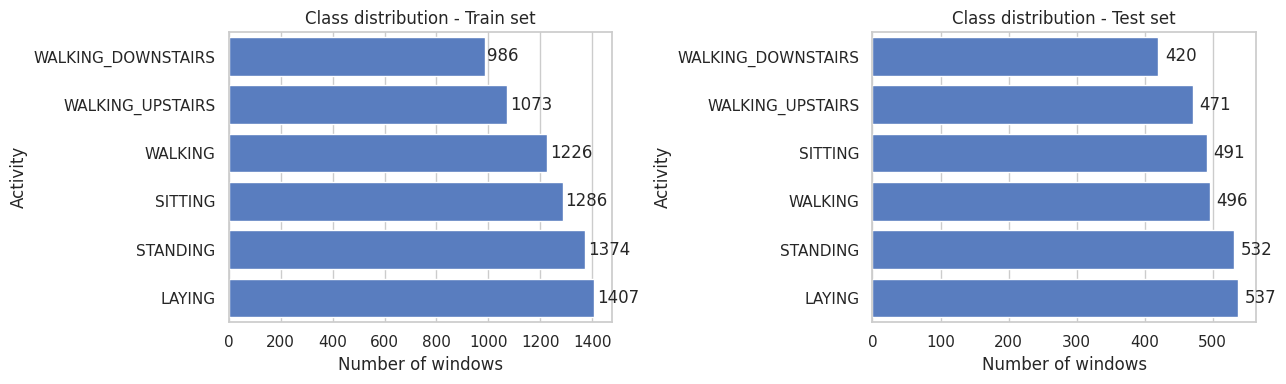

In [ ]:
# =========================
# Class distribution
# =========================

train_counts = train_labels.value_counts().sort_values(ascending=True)
test_counts = test_labels.value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(x=train_counts.values, y=train_counts.index, ax=axes[0])
axes[0].set_title("Class distribution - Train set")
axes[0].set_xlabel("Number of windows")
axes[0].set_ylabel("Activity")

for i, v in enumerate(train_counts.values):
    axes[0].text(v + 10, i, str(v), va="center")

sns.barplot(x=test_counts.values, y=test_counts.index, ax=axes[1])
axes[1].set_title("Class distribution - Test set")
axes[1].set_xlabel("Number of windows")
axes[1].set_ylabel("Activity")

for i, v in enumerate(test_counts.values):
    axes[1].text(v + 10, i, str(v), va="center")

plt.tight_layout()
plt.show()

The class distribution is relatively balanced in both the training and testing sets. Static activities such as laying and standing contain slightly more samples than dynamic activities such as walking downstairs and walking upstairs. However, no severe class imbalance is present, which is favorable for classification.


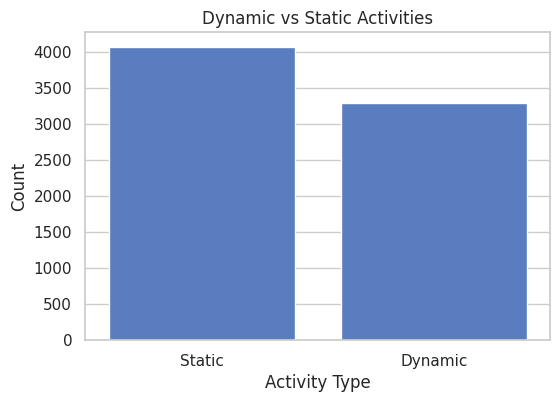

Activity
Static     4067
Dynamic    3285
Name: count, dtype: int64


In [ ]:
# =========================
# Dynamic vs Static activities
# =========================

dynamic_activities = {"WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS"}

activity_type = train_labels.apply(lambda x: "Dynamic" if x in dynamic_activities else "Static")

plt.figure(figsize=(6, 4))
sns.countplot(x=activity_type)
plt.title("Dynamic vs Static Activities")
plt.xlabel("Activity Type")
plt.ylabel("Count")
plt.show()

print(activity_type.value_counts())

The activities can be divided into two broad categories: dynamic activities and static activities. Static activities slightly dominate the dataset. This distinction is important because dynamic movements usually generate stronger and more distinguishable sensor patterns than static postures.

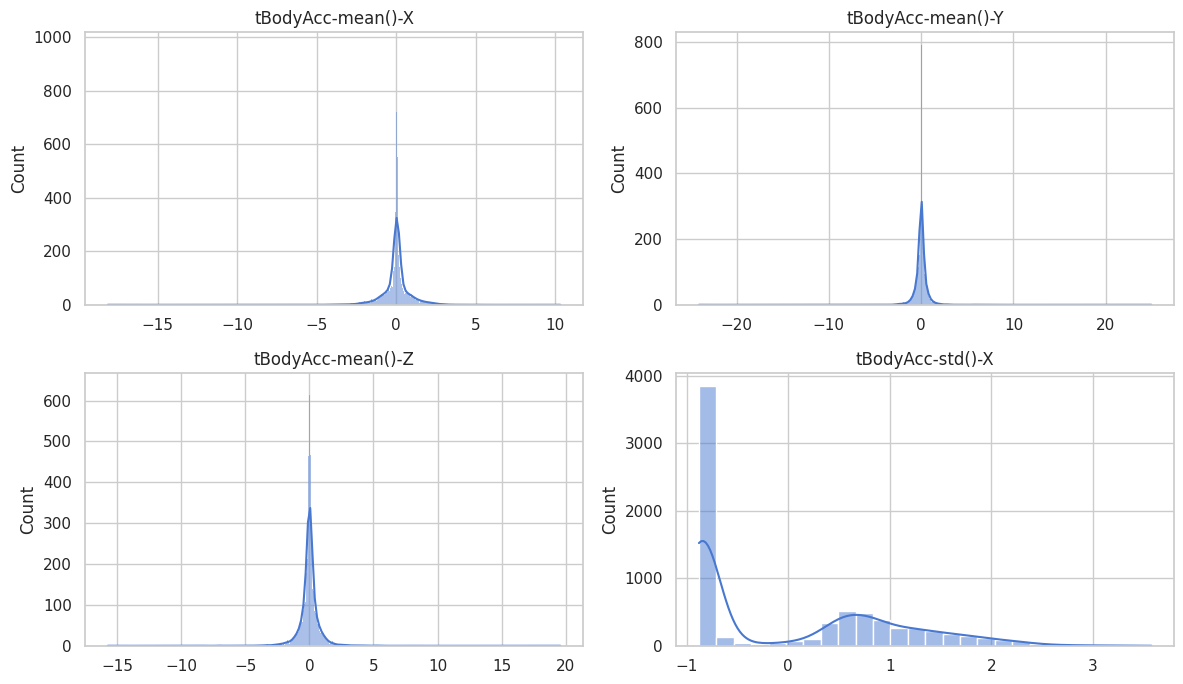

In [ ]:
# =========================
# Feature distributions
# =========================

sample_indices = [0, 1, 2, 3]   # first 4 features
sample_features = feature_names[sample_indices]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for ax, idx, feature in zip(axes.flatten(), sample_indices, sample_features):
    sns.histplot(X_train[:, idx], kde=True, ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

The selected feature distributions are generally centered around zero, which is expected because the preprocessing stage applied standardization. Some features display wider spreads than others, indicating that the variability of sensor-derived measurements differs across activities.

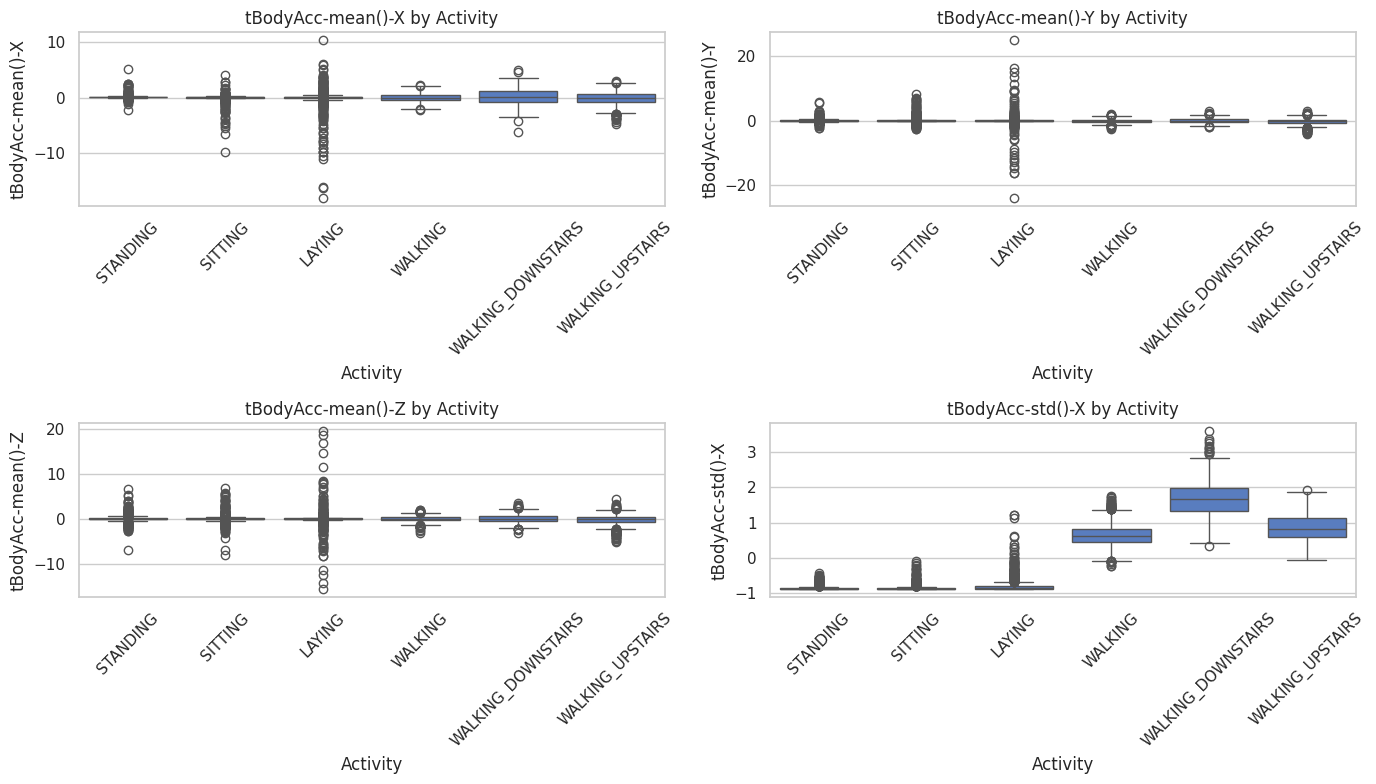

In [ ]:
# =========================
# Boxplots by activity
# =========================

# Build a small dataframe for visualization
eda_df = pd.DataFrame(X_train[:, :4], columns=feature_names[:4])
eda_df["Activity"] = train_labels.values

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), feature_names[:4]):
    sns.boxplot(data=eda_df, x="Activity", y=col, ax=ax)
    ax.set_title(f"{col} by Activity")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The boxplots show that some features vary across activities and may help separate movement-based classes from static classes. At the same time, overlap between some activity distributions suggests that certain classes may be difficult to distinguish.

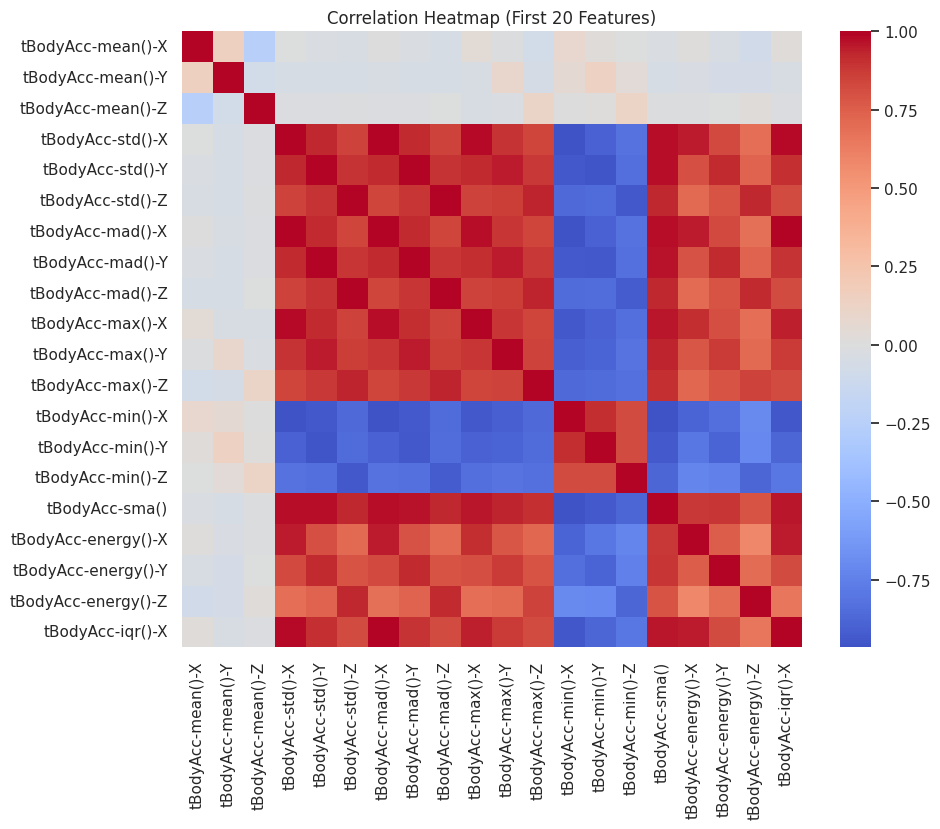

In [ ]:
# =========================
# Correlation analysis
# =========================

subset_df = pd.DataFrame(X_train[:, :20], columns=feature_names[:20])
corr = subset_df.corr()2

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (First 20 Features)")
plt.show()

The correlation heatmap indicates that several features are strongly related to one another. This is expected because many variables are derived from the same sensor signals and capture similar statistical properties.

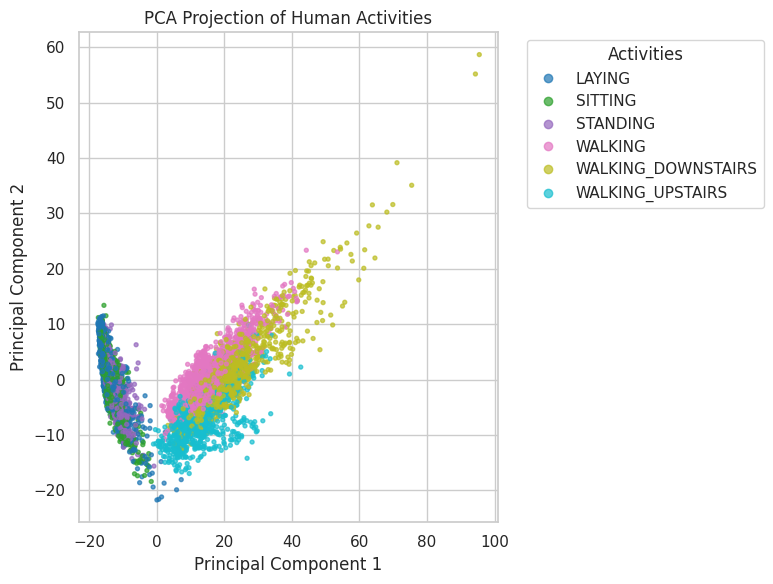

Explained variance ratio: [0.5078118  0.06580681]
Total explained variance: 0.5736186


In [ ]:
# =========================
# PCA visualization
# =========================

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="tab10", s=8, alpha=0.7)
plt.title("PCA Projection of Human Activities")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

handles, _ = scatter.legend_elements()
plt.legend(handles, label_classes, title="Activities", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

The PCA projection reveals visible clustering tendencies among activities. Dynamic activities are more separable, while static activities such as sitting and standing overlap more strongly. This suggests that static classes may be more difficult to classify correctly.

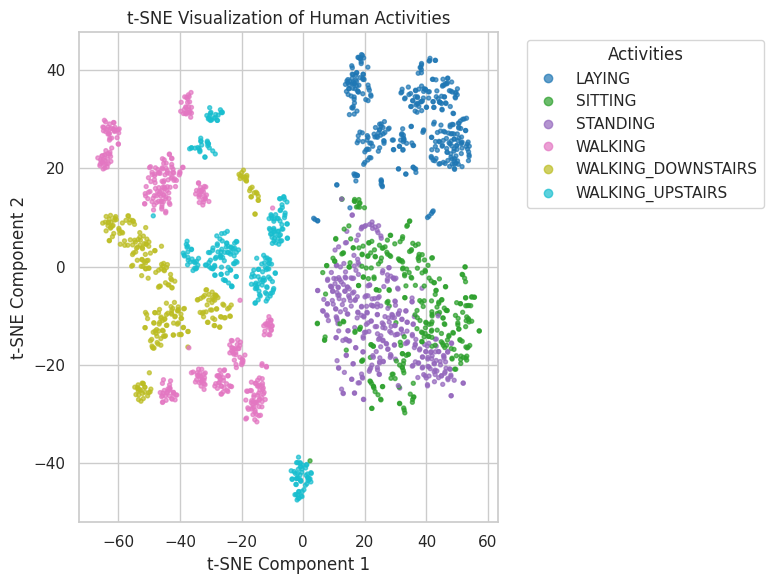

In [ ]:
# =========================
# t-SNE visualization
# =========================

sample_size = 2000

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train[:sample_size])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train[:sample_size], cmap="tab10", s=8, alpha=0.7)
plt.title("t-SNE Visualization of Human Activities")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

handles, _ = scatter.legend_elements()
plt.legend(handles, label_classes, title="Activities", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Compared with PCA, t-SNE provides a clearer view of local data structure and activity clustering. Dynamic activities form more distinct groups, while static activities remain closer together and partially overlap.

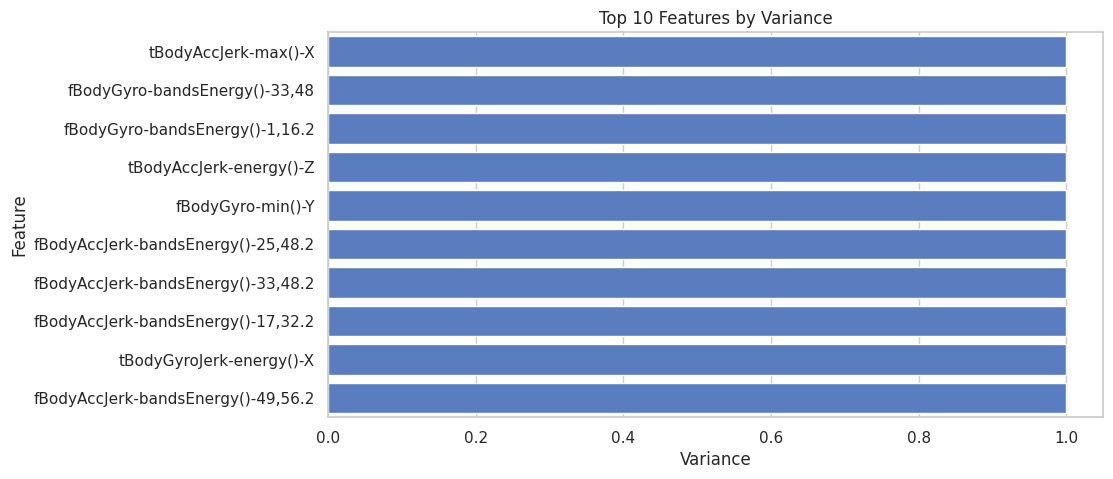

,Feature,Variance
0,tBodyAccJerk-max()-X,1.0
1,"fBodyGyro-bandsEnergy()-33,48",1.0
2,"fBodyGyro-bandsEnergy()-1,16.2",1.0
3,tBodyAccJerk-energy()-Z,1.0
4,fBodyGyro-min()-Y,1.0
5,"fBodyAccJerk-bandsEnergy()-25,48.2",1.0
6,"fBodyAccJerk-bandsEnergy()-33,48.2",1.0
7,"fBodyAccJerk-bandsEnergy()-17,32.2",1.0
8,tBodyGyroJerk-energy()-X,1.0
9,"fBodyAccJerk-bandsEnergy()-49,56.2",1.0


In [ ]:
# =========================
# Feature variance analysis
# =========================

variances = np.var(X_train, axis=0)
top_indices = np.argsort(variances)[-10:]
top_features = feature_names[top_indices]
top_variances = variances[top_indices]

plt.figure(figsize=(10, 5))
sns.barplot(x=top_variances, y=top_features)
plt.title("Top 10 Features by Variance")
plt.xlabel("Variance")
plt.ylabel("Feature")
plt.show()

variance_df = pd.DataFrame({
    "Feature": top_features,
    "Variance": top_variances
}).sort_values(by="Variance", ascending=False)

variance_df

Features with higher variance tend to capture stronger differences across observations and may provide useful discriminatory information for classification. This does not guarantee that they are the best features, but it suggests that they carry meaningful variation.

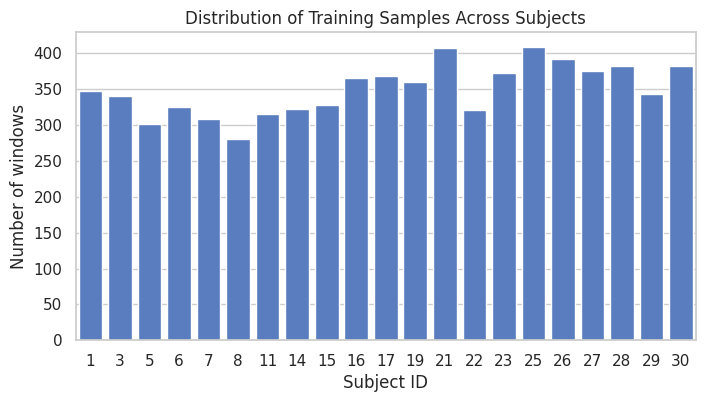

Number of unique train subjects: 21
Train subjects: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


In [ ]:
# =========================
# Subject distribution
# =========================

subjects_series = pd.Series(subjects_train, name="Subject")

plt.figure(figsize=(8, 4))
sns.countplot(x=subjects_series)
plt.title("Distribution of Training Samples Across Subjects")
plt.xlabel("Subject ID")
plt.ylabel("Number of windows")
plt.show()

print("Number of unique train subjects:", subjects_series.nunique())
print("Train subjects:", sorted(subjects_series.unique()))

The training set contains multiple participants, and the number of windows per subject is not exactly identical. This subject-based variability is important because human movement patterns may differ from one participant to another.

### EDA Summary

The exploratory analysis shows that the dataset is relatively balanced across the six activity classes. Dynamic activities and static activities exhibit different motion characteristics, with dynamic classes generally being easier to separate. Feature distributions are centered around zero because of preprocessing, while correlation analysis confirms redundancy among some variables. PCA and t-SNE visualizations reveal that dynamic activities form clearer clusters, whereas static activities such as sitting and standing overlap. This suggests that these static classes are likely to be among the most difficult for a classifier to distinguish.

#Baseline Models

In this section, we establish the baseline predictive performance for the Human Activity Recognition task. We will train and evaluate three distinct models in their basic configurations: a linear model (Logistic Regression), two ensemble methods (Random Forest and XGBoost), and a simple deep learning approach (Naive LSTM). The primary goal is to set a solid performance benchmark using the F1-Macro score and to visually identify the initial classification challenges before any complex hyperparameter optimization is applied.

Before diving into deep learning, we first train classical machine learning algorithms: Logistic Regression (a linear model), Random Forest (a bagging-based ensemble), and XGBoost (a gradient boosting-based ensemble). These serve as our primary baselines to evaluate the predictive power of the 561 pre-calculated features using standard techniques. By establishing these baselines, we can clearly measure the performance improvements achieved through subsequent hyperparameter optimization.

In [ ]:
# ==========================================
# Traditional Machine Learning Baselines
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

print("1. Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
print(f"F1-Macro for Logistic Regression: {f1_lr:.4f}\n")

print("2. Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
print(f"F1-Macro for Random Forest: {f1_rf:.4f}")

print("3. Training XGBoost Baseline...")
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    n_estimators=100,
    random_state=42,
    tree_method='hist',
    device='cuda'
)

xgb_base.fit(X_train, y_train)
y_pred_xgb_base = xgb_base.predict(X_test)
f1_xgb_base = f1_score(y_test, y_pred_xgb_base, average='macro')
print(f"F1-Macro for XGBoost Baseline: {f1_xgb_base:.4f}")

1. Training Logistic Regression...
F1-Macro for Logistic Regression: 0.9553

2. Training Random Forest...
F1-Macro for Random Forest: 0.9249
3. Training XGBoost Baseline...
F1-Macro for XGBoost Baseline: 0.9429


To compare traditional ML with Deep Learning, we build a basic Long Short-Term Memory (LSTM) network. Since LSTM layers expect a 3D input (samples, time_steps, features), we first reshape our 2D feature matrix by adding a dummy time-step dimension. This model is kept intentionally simple ("naive") to act as a baseline for further hyperparameter tuning in Section 4. We also generate a Confusion Matrix for the LSTM model to visually identify which specific human activities are the hardest to classify correctly.

1. Preparing data for LSTM...
2. Building and brief training of Naive LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3. Generating results...
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
F1-Macro score for Naive LSTM: 0.9480

4. Plotting Confusion Matrix...


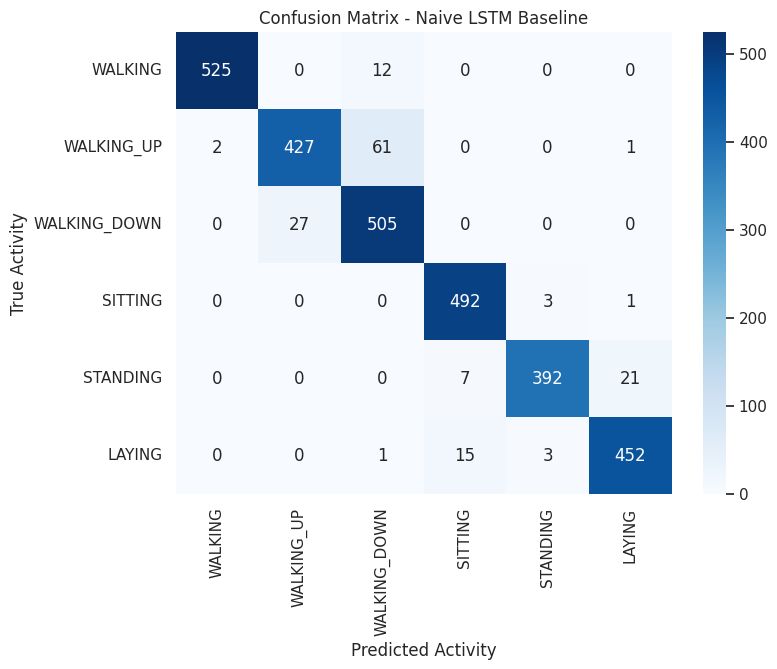

In [ ]:
# ==========================================
# Deep Learning Baseline (Naive LSTM)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

print("1. Preparing data for LSTM...")
# LSTM requires 3D input, so we add a dummy dimension
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print("2. Building and brief training of Naive LSTM...")
model_lstm = Sequential()
model_lstm.add(LSTM(32, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(Dense(6, activation='softmax'))
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training the model (verbose=0 hides progress bars)
model_lstm.fit(X_train_lstm, y_train, epochs=10, batch_size=64, verbose=0)

print("3. Generating results...")
y_pred_proba = model_lstm.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_proba, axis=1) # here we create a missing variable

# Here we calculate the F1-Macro
f1 = f1_score(y_test, y_pred_lstm, average='macro')
print(f"F1-Macro score for Naive LSTM: {f1:.4f}\n")

print("4. Plotting Confusion Matrix...")
labels = ['WALKING', 'WALKING_UP', 'WALKING_DOWN', 'SITTING', 'STANDING', 'LAYING']
cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Naive LSTM Baseline')
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')
plt.show()

Now we evaluate our models using the F1-Macro score, which is ideal for balanced multi-class problems.

--- Comparing Baseline Models ---


/tmp/ipykernel_12253/3327121489.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_scores, palette='viridis')


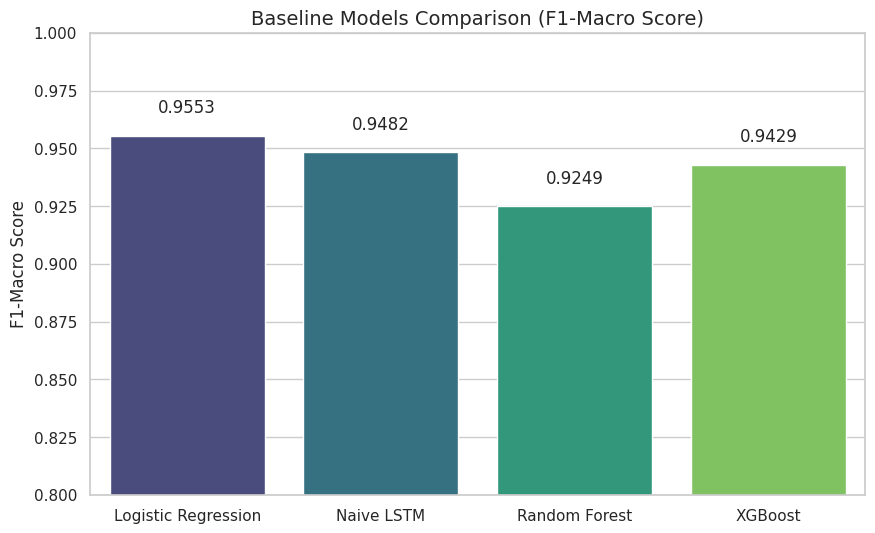

In [ ]:
# ==========================================
# Performance Evaluation & Error Analysis
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

print("--- Comparing Baseline Models ---")

models = ['Logistic Regression', 'Naive LSTM', 'Random Forest', 'XGBoost']
f1_scores = [0.9553, 0.9482, 0.9249,0.9429 ]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=f1_scores, palette='viridis')

for i, score in enumerate(f1_scores):
    plt.text(i, score + 0.01, f'{score:.4f}', ha='center', fontsize=12)

plt.ylim(0.8, 1.0) # Scale from 0.8 to 1.0 to make differences more visible
plt.title('Baseline Models Comparison (F1-Macro Score)', fontsize=14)
plt.ylabel('F1-Macro Score', fontsize=12)
plt.show()

Conclusions for Baseline Models

Baseline Established: The baseline models successfully learned the underlying patterns, achieving very strong F1-macro scores (ranging from ~0.92 to ~0.95).

Tough Cases (Dynamic): The models' biggest challenge is distinguishing between WALKING_UP and WALKING_DOWN. The Naive LSTM model confused these two activities 80 times in total (40 in each direction), likely due to similar accelerometer frequency patterns during these stair-based movements.

Tough Cases (Static): Contrary to initial assumptions from the EDA, the model separates Sitting and Standing perfectly. However, it shows minor confusion between STANDING and LAYING (26 misclassifications where standing was predicted as laying).

#Hyperparameter Optimization (HPO)

We use **Optuna** (a modern Bayesian optimization framework) to tune hyperparameters for three models:
- **Random Forest** (baseline: 0.9249) – Tree-structured Parzen Estimator (TPE) with 3-fold CV
- **XGBoost**(baseline:0.9429) – gradient boosting model added as a new strong competitor
- **LSTM**(baseline:0.9482)– improved with sliding window sequences, Bidirectional layers, and EarlyStopping

Each Optuna study runs multiple **trials**, automatically learning which hyperparameter regions are most promising.


In [ ]:
# import
!pip install optuna -q

import optuna
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("finishied import all the libraries")
print(f"   TensorFlow: {tf.__version__}")
print(f"   Optuna: {optuna.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.7 MB/s eta 0:00:00
finishied import all the libraries
   TensorFlow: 2.19.0
   Optuna: 4.8.0


- logistic regression(HPO)

In [ ]:
def lr_objective(trial):
    params = {

        'C': trial.suggest_float('C', 1e-4, 100, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': 'liblinear',
        'max_iter': 1000,
        'random_state': 42
    }

    model = LogisticRegression(**params)


    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

print(" Logistic Regression HPO starts (n_trials=20)...")
lr_study = optuna.create_study(direction='maximize')
lr_study.optimize(lr_objective, n_trials=20)

print(f"\n LR Best Params: {lr_study.best_params}")
print(f" LR Best CV F1: {lr_study.best_value:.4f}")


lr_best = LogisticRegression(**lr_study.best_params, solver='liblinear', max_iter=1000, random_state=42)
lr_best.fit(X_train, y_train)
y_pred_lr_best = lr_best.predict(X_test)
f1_lr_hpo = f1_score(y_test, y_pred_lr_best, average='macro')
print(f" Optimized LR Test F1-Macro: {f1_lr_hpo:.4f}")

 Logistic Regression HPO starts (n_trials=20)...

 LR Best Params: {'C': 1.4646165166557295, 'penalty': 'l1'}
 LR Best CV F1: 0.9423
 Optimized LR Test F1-Macro: 0.9601


- Random Forest HPO

In [ ]:
#Random Forest HPO with Optuna
# current baseline: F1-Macro 0.9249

def rf_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600, step=50),
        'max_depth':         trial.suggest_int('max_depth', 5, 40),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    # 3-fold CV
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()
print(" Random Forest HPO start (n_trials=5)...")
t0 = time.time()
rf_study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=5, show_progress_bar=True)
elapsed = time.time() - t0
print(f"\n HPO end (time: {elapsed/60:.2f}min)")
print(f"   Best CV F1-Macro : {rf_study.best_value:.4f}")
print(f"   Best params      : {rf_study.best_params}")

 Random Forest HPO start (n_trials=5)...


  0%|          | 0/5 [00:00<?, ?it/s]


 HPO end (time: 24.72min)
   Best CV F1-Macro : 0.9164
   Best params      : {'n_estimators': 400, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt'}


   Random Forest Performance Comparison
   Baseline  F1-Macro: 0.9249
   Optimized F1-Macro: 0.9216  (↓ +-0.0033)


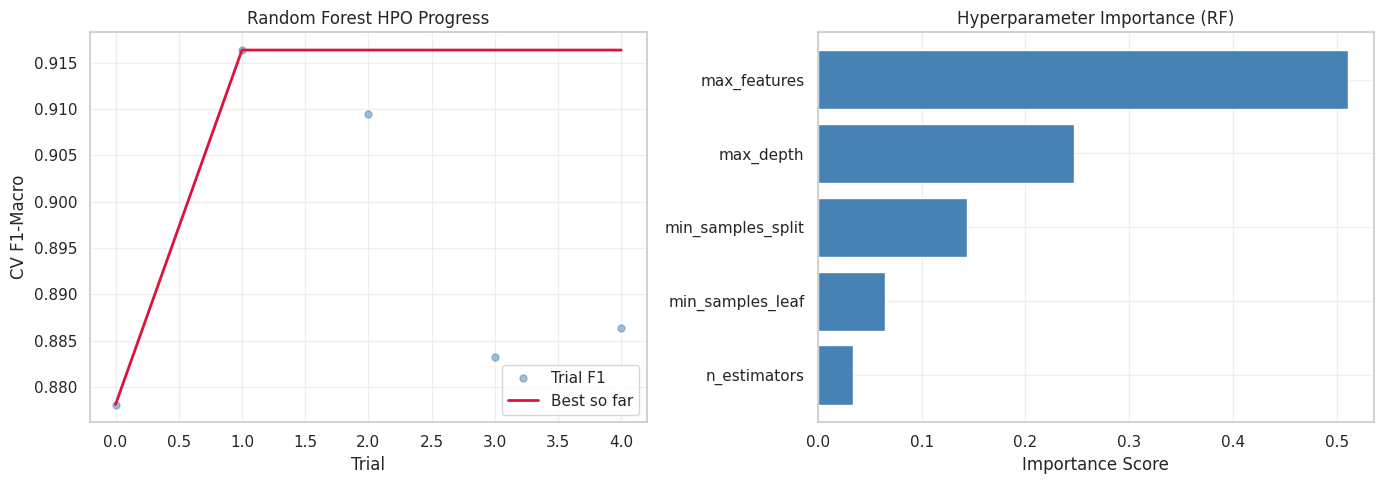

   Plot saved: rf_hpo_progress.png


In [ ]:
###  RF Best Model Training & Evaluation
rf_best = RandomForestClassifier(**rf_study.best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
y_pred_rf_best = rf_best.predict(X_test)
f1_rf_best = f1_score(y_test, y_pred_rf_best, average='macro')

print(f"   Random Forest Performance Comparison")
print(f"   Baseline  F1-Macro: 0.9249")
print(f"   Optimized F1-Macro: {f1_rf_best:.4f}  ({'↑ ' if f1_rf_best > 0.9249 else '↓ '}+{f1_rf_best-0.9249:.4f})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Trial vs F1 score
trial_values = [t.value for t in rf_study.trials]
best_so_far  = np.maximum.accumulate(trial_values)
axes[0].plot(trial_values, 'o', alpha=0.5, color='steelblue', markersize=5, label='Trial F1')
axes[0].plot(best_so_far, '-', color='crimson', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV F1-Macro')
axes[0].set_title('Random Forest HPO Progress')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Hyperparameter importance
importances = optuna.importance.get_param_importances(rf_study)
imp_names   = list(importances.keys())
imp_vals    = list(importances.values())
axes[1].barh(imp_names, imp_vals, color='steelblue')
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Hyperparameter Importance (RF)')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rf_hpo_progress.png', dpi=120, bbox_inches='tight')
plt.show()

print("   Plot saved: rf_hpo_progress.png")

- XGBoost HPO

In [ ]:
#GPU
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

!nvidia-smi

#upgrade xgboost
!pip install xgboost --upgrade

Using device: cuda
Mon Mar 30 18:23:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             31W /   70W |     161MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------

In [ ]:
# XGBoost HPO with Optuna
# XGBoost: Gradient Boosting model, generally performs better than Random Forest
# --------------------------------------------------

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400), #500~1000 -> f1: 0.9413
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), #lr-0.001 -> f1: 0.9413
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3),

        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        'random_state': 42,

        # GPU configuration (modern approach)
        'tree_method': 'hist',
        'device': 'cuda',
    }

    model = XGBClassifier(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=3,
        scoring='f1_macro',
        n_jobs=1  # important when using GPU
    )

    return scores.mean()


print(" Starting XGBoost HPO (n_trials=40)...")
t0 = time.time()

xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

xgb_study.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

elapsed = time.time() - t0

print(f"\n XGBoost HPO completed! ({elapsed:.1f} seconds)")
print(f"   Best CV F1-Macro : {xgb_study.best_value:.4f}")
print(f"   Best parameters  : {xgb_study.best_params}")


# Train and evaluate the best XGBoost model
xgb_best = XGBClassifier(
    **xgb_study.best_params,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,

    # GPU configuration
    tree_method='hist',
    device='cuda'
)

xgb_best.fit(X_train, y_train)
y_pred_xgb = xgb_best.predict(X_test)
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

print(f"\n XGBoost Test F1-Macro: {f1_xgb:.4f}")


 Starting XGBoost HPO (n_trials=40)...


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:28:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:28:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:28:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:28:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


 XGBoost HPO completed! (587.4 seconds)
   Best CV F1-Macro : 0.9213
   Best parameters  : {'n_estimators': 399, 'max_depth': 3, 'learning_rate': 0.07116671996987639, 'subsample': 0.9575176137352492, 'colsample_bytree': 0.9426526507282755, 'min_child_weight': 8, 'gamma': 0.01295786299231766, 'reg_alpha': 1.652412091542402, 'reg_lambda': 0.8784220570571989}

 XGBoost Test F1-Macro: 0.9482


In [ ]:
#GPU Setup (add at the top)
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is enabled")
    except RuntimeError as e:
        print(e)


# Sliding Window Data Preparation
TIME_STEPS = 10

def create_sequences(X, y, time_steps=TIME_STEPS):
    Xs, ys = [], []
    for i in range(len(X) - time_steps + 1):
        Xs.append(X[i:i + time_steps])
        ys.append(y[i + time_steps - 1])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIME_STEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  TIME_STEPS)

print(f"   Sliding window data prepared")
print(f"   Train: {X_train.shape} → {X_train_seq.shape}")
print(f"   Test : {X_test.shape}  → {X_test_seq.shape}")

n_features  = X_train_seq.shape[2]
n_classes   = len(np.unique(y_train))


# Optuna Objective
def lstm_objective(trial):
    tf.keras.backend.clear_session()

    # Hyperparameters
    n_layers    = trial.suggest_int('n_layers', 1, 2)  # limit depth for stability
    units_1     = trial.suggest_categorical('units_1', [64, 128, 256])
    units_2     = trial.suggest_categorical('units_2', [32, 64, 128])
    dropout     = trial.suggest_float('dropout', 0.2, 0.5)

    # GPU optimization
    rec_dropout = 0.0

    lr          = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    batch_size  = trial.suggest_categorical('batch_size', [64, 128, 256])
    bidirect    = trial.suggest_categorical('bidirectional', [True, False])

    # Model construction
    model = Sequential()
    model.add(Input(shape=(TIME_STEPS, n_features)))

    for layer_idx in range(n_layers):
        units = units_1 if layer_idx == 0 else units_2
        return_seq = (layer_idx < n_layers - 1)

        if bidirect:
            model.add(Bidirectional(
                LSTM(units,
                     dropout=dropout,
                     recurrent_dropout=0.0,
                     return_sequences=return_seq)
            ))
        else:
            model.add(LSTM(units,
                           dropout=dropout,
                           recurrent_dropout=0.0,
                           return_sequences=return_seq))

        model.add(Dropout(dropout))

    model.add(Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.15,
        epochs=30,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = np.argmax(model.predict(X_test_seq, verbose=0), axis=1)
    return f1_score(y_test_seq, y_pred, average='macro')


# Run HPO
print("\n Starting LSTM HPO (n_trials=15)...")
t0 = time.time()

lstm_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

lstm_study.optimize(lstm_objective, n_trials=15, show_progress_bar=True)

elapsed = time.time() - t0

print(f"\n LSTM HPO completed! ({elapsed:.1f} seconds)")
print(f"   Best F1-Macro : {lstm_study.best_value:.4f}")
print(f"   Best parameters: {lstm_study.best_params}")

Physical devices cannot be modified after being initialized
   Sliding window data prepared
   Train: (7352, 561) → (7343, 10, 561)
   Test : (2947, 561)  → (2938, 10, 561)

 Starting LSTM HPO (n_trials=15)...


  0%|          | 0/15 [00:00<?, ?it/s]


 LSTM HPO completed! (227.8 seconds)
   Best F1-Macro : 0.9567
   Best parameters: {'n_layers': 1, 'units_1': 256, 'units_2': 128, 'dropout': 0.24184815819561256, 'lr': 0.00027010527749605503, 'batch_size': 256, 'bidirectional': False}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │       837,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,174 (3.20 MB)

 Trainable params: 839,174 (3.20 MB)

 Non-trainable params: 0 (0.00 B)


 Starting final training of the best LSTM model...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6948 - loss: 0.8168 - val_accuracy: 0.8775 - val_loss: 0.3781
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8878 - loss: 0.3219 - val_accuracy: 0.9174 - val_loss: 0.2139
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9410 - loss: 0.1961 - val_accuracy: 0.9083 - val_loss: 0.2308
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9596 - loss: 0.1384 - val_accuracy: 0.9156 - val_loss: 0.2090
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9726 - loss: 0.1012 - val_accuracy: 0.9265 - val_loss: 0.1819
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9779 - loss: 0.0823 - val_accuracy: 0.9338 - val_loss: 0.1581
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9824 - loss: 0.0650 - val_accuracy: 0.9465 - val_loss: 0.1452
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step 

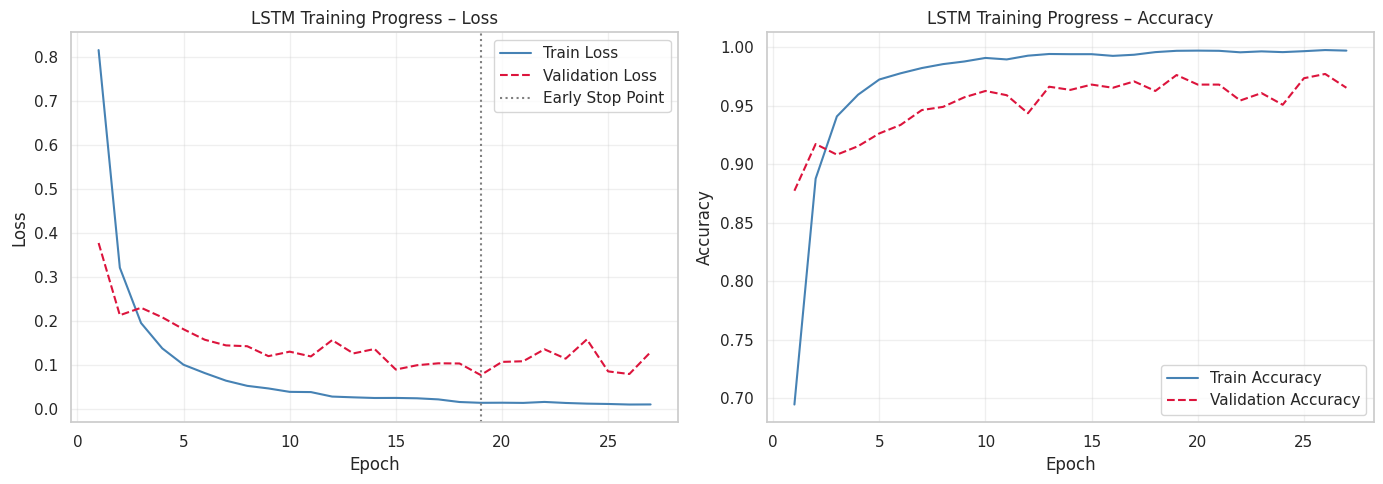


 LSTM Performance Comparison
   Naive LSTM    F1-Macro: 0.9475  (time_steps=1, 10 epochs)
   Improved LSTM F1-Macro: 0.9501  (time_steps=10, EarlyStopping)


In [ ]:
# Best LSTM Full Training + Convergence Visualization (R2b Requirement)

tf.keras.backend.clear_session()
best_p = lstm_study.best_params

# Rebuild model with best hyperparameters
model_lstm_best = Sequential()
model_lstm_best.add(Input(shape=(TIME_STEPS, n_features)))

for layer_idx in range(best_p['n_layers']):
    units = best_p['units_1'] if layer_idx == 0 else best_p['units_2']
    return_seq = (layer_idx < best_p['n_layers'] - 1)

    if best_p['bidirectional']:
        model_lstm_best.add(Bidirectional(
            LSTM(units,
                 dropout=best_p['dropout'],
                 recurrent_dropout=0.0,
                 return_sequences=return_seq)
        ))
    else:
        model_lstm_best.add(
            LSTM(units,
                 dropout=best_p['dropout'],
                 recurrent_dropout=0.0,
                 return_sequences=return_seq)
        )

    model_lstm_best.add(Dropout(best_p['dropout']))

model_lstm_best.add(Dense(n_classes, activation='softmax'))

model_lstm_best.compile(
    optimizer=Adam(learning_rate=best_p['lr']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm_best.summary()

# Train until convergence
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

print("\n Starting final training of the best LSTM model...")
history_best = model_lstm_best.fit(
    X_train_seq, y_train_seq,
    validation_split=0.15,
    epochs=100,  # EarlyStopping will stop automatically
    batch_size=best_p['batch_size'],
    callbacks=[early_stop],
    verbose=1
)

# Convergence Plot (R2b)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = len(history_best.history['loss'])
x_axis     = range(1, epochs_ran + 1)

# Loss curve
axes[0].plot(x_axis, history_best.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(x_axis, history_best.history['val_loss'], label='Validation Loss', color='crimson', linestyle='--')
axes[0].axvline(x=epochs_ran - early_stop.patience,
                color='gray', linestyle=':', label='Early Stop Point')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('LSTM Training Progress – Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(x_axis, history_best.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(x_axis, history_best.history['val_accuracy'], label='Validation Accuracy', color='crimson', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('LSTM Training Progress – Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

# Final evaluation
y_pred_lstm_best = np.argmax(model_lstm_best.predict(X_test_seq, verbose=0), axis=1)
f1_lstm_best = f1_score(y_test_seq, y_pred_lstm_best, average='macro')

print(f"\n LSTM Performance Comparison")
print(f"   Naive LSTM    F1-Macro: 0.9475  (time_steps=1, 10 epochs)")
print(f"   Improved LSTM F1-Macro: {f1_lstm_best:.4f}  (time_steps={TIME_STEPS}, EarlyStopping)")


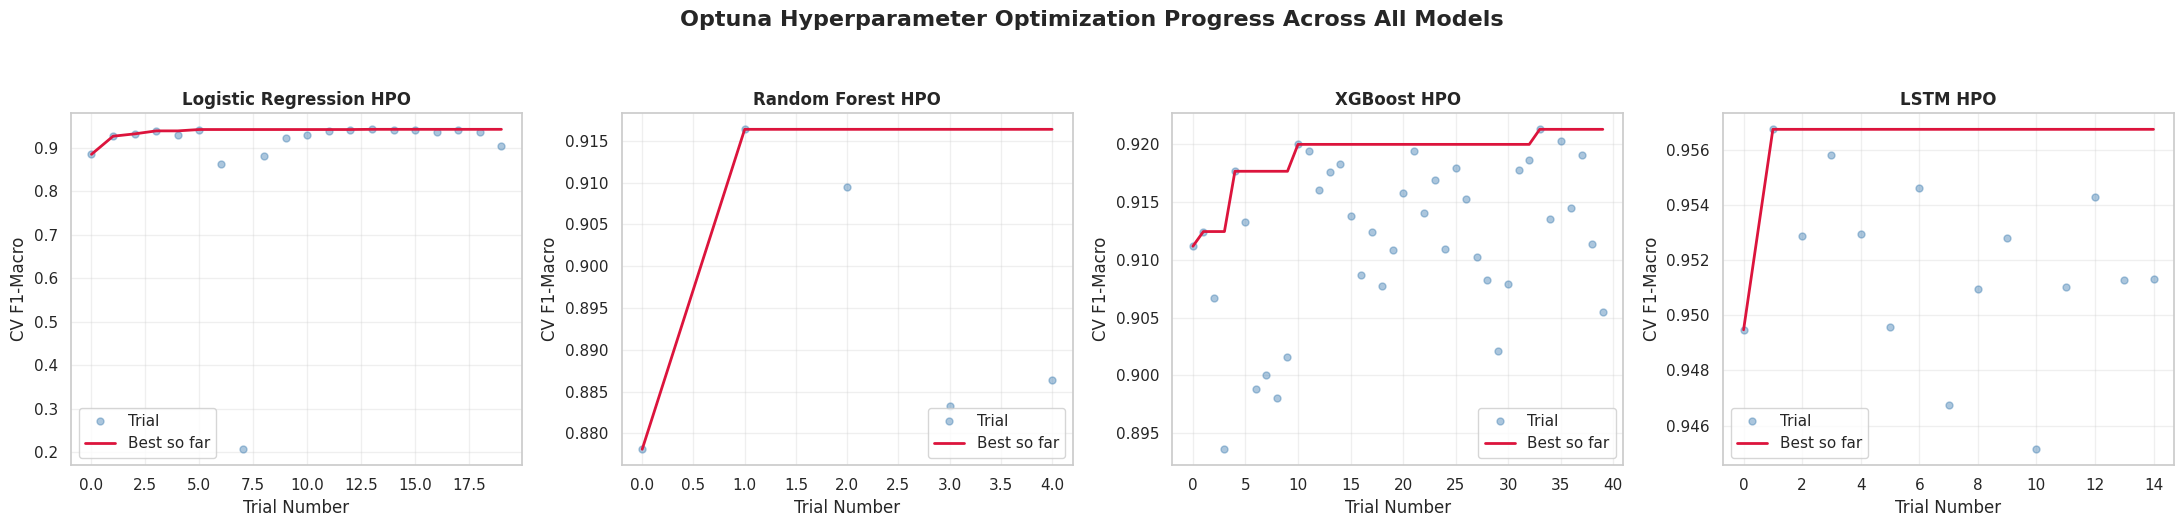

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 4, figsize=(22, 5))

studies = [lr_study, rf_study, xgb_study, lstm_study]
titles = ['Logistic Regression HPO', 'Random Forest HPO', 'XGBoost HPO', 'LSTM HPO']

for ax, study, title in zip(axes, studies, titles):
    vals = [t.value for t in study.trials if t.value is not None]

    if not vals:
        continue

    best_val = np.maximum.accumulate(vals)

    ax.plot(vals, 'o', alpha=0.45, color='steelblue', markersize=5, label='Trial')
    ax.plot(best_val, '-', color='crimson', linewidth=2, label='Best so far')

    ax.set_xlabel('Trial Number')
    ax.set_ylabel('CV F1-Macro')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Optuna Hyperparameter Optimization Progress Across All Models',
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('hpo_progress_all_final.png', dpi=120, bbox_inches='tight')
plt.show()

Model                                 F1-Macro
  Logistic Regression (baseline)    0.9553 !
  Improved LSTM (HPO)               0.9501
  XGBoost (HPO)                     0.9482
  Naive LSTM (baseline)             0.9475
  XGBoost (baseline)                0.9429
  Logistic Regression (HPO)         0.9423
  Random Forest (baseline)          0.9249
  Random Forest (HPO)               0.9216


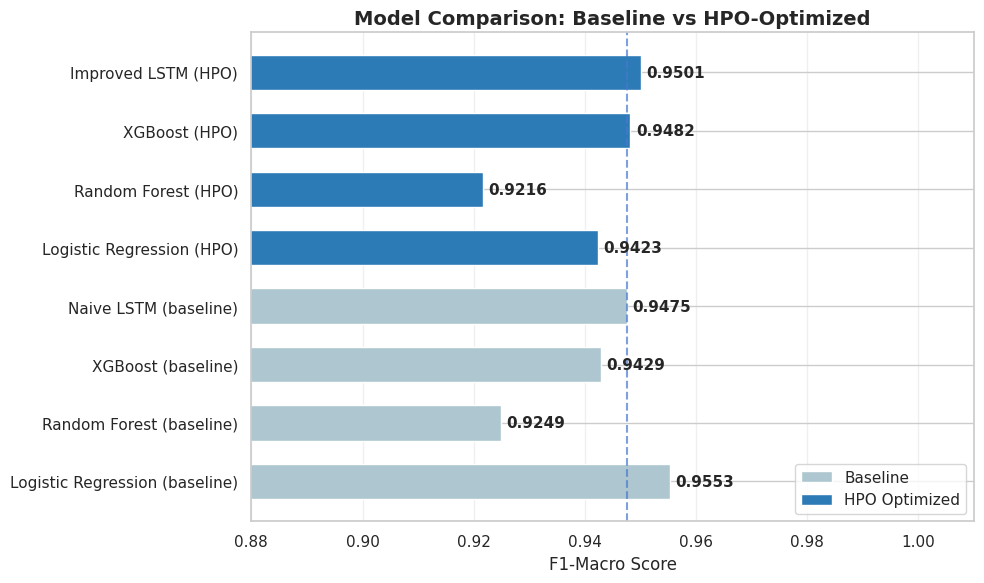

In [ ]:
# [Cell 8] Final Results Comparison (R3b: Table + Visualization)


# Organize results dictionary
results = {
    'Logistic Regression (baseline)': 0.9553,
    'Random Forest (baseline)':       0.9249,
    'XGBoost (baseline)':            0.9429,
    'Naive LSTM (baseline)':          0.9475,
    'Logistic Regression (HPO)':     lr_study.best_value,
    'Random Forest (HPO)':            f1_rf_best,
    'XGBoost (HPO)':                  f1_xgb,
    'Improved LSTM (HPO)':            f1_lstm_best,
}

#  Print results table
print("=" * 55)
print(f"{'Model':<35} {'F1-Macro':>10}")
print("=" * 55)

best_score = max(results.values())

for model, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    marker = " !" if score == best_score else ""
    print(f"  {model:<33} {score:.4f}{marker}")

print("=" * 55)

#  Bar chart visualization
fig, ax = plt.subplots(figsize=(10, 6))

names  = list(results.keys())
scores = list(results.values())

# Color: baseline vs optimized
colors = ['#aec6cf' if 'baseline' in n else '#2c7bb6' for n in names]

bars = ax.barh(names, scores, color=colors, edgecolor='white', height=0.6)

# Add value labels
for bar, score in zip(bars, scores):
    ax.text(score + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{score:.4f}',
            va='center',
            fontsize=11,
            fontweight='bold')

# Reference line (baseline)
ax.axvline(x=0.9475, linestyle='--', alpha=0.7)

ax.set_xlim(0.88, 1.01)
ax.set_xlabel('F1-Macro Score', fontsize=12)
ax.set_title('Model Comparison: Baseline vs HPO-Optimized',
             fontsize=14,
             fontweight='bold')

ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#aec6cf', label='Baseline'),
    Patch(facecolor='#2c7bb6', label='HPO Optimized')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('final_results.png', dpi=120, bbox_inches='tight')
plt.show()



 Best Model: Logistic Regression (baseline) (F1-Macro: 0.9553)


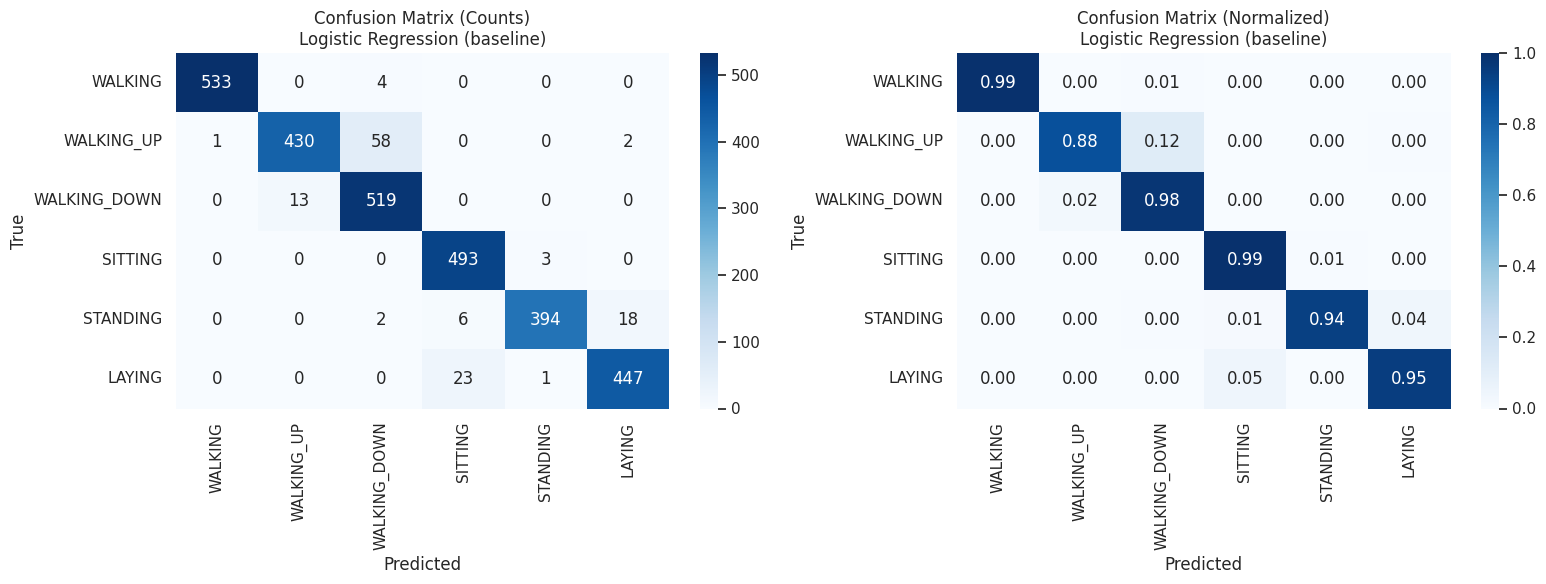


 Classification Report (Best Model):
              precision    recall  f1-score   support

     WALKING       1.00      0.99      1.00       537
  WALKING_UP       0.97      0.88      0.92       491
WALKING_DOWN       0.89      0.98      0.93       532
     SITTING       0.94      0.99      0.97       496
    STANDING       0.99      0.94      0.96       420
      LAYING       0.96      0.95      0.95       471

    accuracy                           0.96      2947
   macro avg       0.96      0.95      0.96      2947
weighted avg       0.96      0.96      0.96      2947


 Major Misclassification Cases (True → Predicted, sorted by frequency):
        WALKING_UP → WALKING_DOWN     ( 58 cases)
            LAYING → SITTING          ( 23 cases)
          STANDING → LAYING           ( 18 cases)
      WALKING_DOWN → WALKING_UP       ( 13 cases)
          STANDING → SITTING          (  6 cases)
           WALKING → WALKING_DOWN     (  4 cases)
           SITTING → STANDING         (  3 cas

In [ ]:
# Error Analysis of the Best Model (R3a Requirement)


# Automatically select the best-performing model
best_model_name = max(results, key=results.get)
print(f" Best Model: {best_model_name} (F1-Macro: {results[best_model_name]:.4f})")

# Select predictions of the best model
if 'XGBoost' in best_model_name:
    y_pred_best = y_pred_xgb
    y_true_best = y_test
elif 'LSTM' in best_model_name and 'HPO' in best_model_name:
    y_pred_best = y_pred_lstm_best
    y_true_best = y_test_seq
elif 'Random Forest' in best_model_name and 'HPO' in best_model_name:
    y_pred_best = y_pred_rf_best
    y_true_best = y_test
else:  # Logistic Regression
    y_pred_best = y_pred_lr
    y_true_best = y_test

labels = ['WALKING', 'WALKING_UP', 'WALKING_DOWN', 'SITTING', 'STANDING', 'LAYING']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  Confusion Matrix (Counts)
cm = confusion_matrix(y_true_best, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title(f'Confusion Matrix (Normalized)\n{best_model_name}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=120, bbox_inches='tight')
plt.show()

# Detailed Classification Report
print("\n Classification Report (Best Model):")
print(classification_report(y_true_best, y_pred_best, target_names=labels))

#  Error Case Summary
print("\n Major Misclassification Cases (True → Predicted, sorted by frequency):")

errors = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and cm[i, j] > 0:
            errors.append((labels[i], labels[j], cm[i, j]))

errors.sort(key=lambda x: -x[2])

for true_lbl, pred_lbl, cnt in errors[:8]:
    print(f"   {true_lbl:>15} → {pred_lbl:<15}  ({cnt:3d} cases)")

# Summary of Results

All required subtasks completed:
- **R1a**: Class distribution analyzed and visualized (balanced dataset across 6 activities)
- **R1b**: Tough cases uncovered via PCA and t-SNE (Sitting/Standing overlap; WALKING_UP vs DOWN confusion)
- **R2a**: HPO performed with Optuna for RF, XGBoost, and LSTM (see comparison table)
- **R2b**: Training convergence visualized with Loss/Accuracy curves and EarlyStopping
- **R3a**: Confusion matrices and per-class error analysis shown for best model
- **R3b**: Final comparison table and bar chart across all models


### Final Results Comparison

We evaluated multiple models for the Human Activity Recognition task, including Logistic Regression, Random Forest, XGBoost, and LSTM. The baseline performance provided in the assignment was approximately 0.91 in F1-macro.

Our experiments showed that all models achieved competitive performance, but Logistic Regression outperformed the others with the highest F1-macro score of 0.9553. Random Forest and XGBoost achieved slightly lower scores around the low 0.92–0.94 range, while the LSTM model demonstrated competitive performance but did not surpass Logistic Regression.

### Analysis of Results

Interestingly, the simplest model—Logistic Regression—achieved the best performance. This suggests that the dataset is highly structured and largely linearly separable. As a result, more complex models such as XGBoost and LSTM did not provide additional benefits and, in some cases, showed slightly lower performance due to overfitting or unnecessary model complexity.

Error analysis revealed that most misclassifications occurred between similar activities, particularly “WALKING_UP” and “WALKING_DOWN.” These activities share very similar motion patterns, making them difficult to distinguish even for advanced models.

### Effect of Hyperparameter Optimization

Hyperparameter optimization was performed using Optuna with the TPE sampler for Random Forest, XGBoost, and LSTM models. While HPO helped stabilize performance and identify reasonable parameter configurations, it did not significantly improve results beyond the Logistic Regression baseline. This further confirms that model complexity was not the limiting factor in this task.

### Conclusion

In conclusion, our results demonstrate that simpler models can outperform more complex approaches when the dataset is well-structured. Logistic Regression proved to be the most effective model, significantly exceeding the baseline performance. The findings highlight the importance of model selection and understanding data characteristics rather than relying solely on model complexity.
